# Revenue & Pricing Analysis — Online Retail
### Portfolio 2 · Data Cleaning + Exploratory Data Analysis

**Objective:** help the business understand the drivers of revenue, and quantify how
**pricing and promotions** affect volume and margin.

**Dataset:** UCI *Online Retail* — all transactions of a UK-based online gift retailer
between Dec 2010 and Dec 2011 (~541k rows). Columns: InvoiceNo, StockCode, Description,
Quantity, InvoiceDate, UnitPrice, CustomerID, Country.

**Important note on derived metrics.** The raw dataset has no cost, discount, or profit
columns. We therefore derive them transparently:
- **Discount / Promotion** — each SKU's *reference (list) price* is its modal unit price;
  any sale below it is a discount, and sales ≥5% below list are flagged as *promoted*.
- **Estimated margin** — using an assumed cost of **50% of list price** (clearly labelled
  as an estimate, not source data).

**Workflow:** 1) Load → 2) Clean → 3) EDA (revenue trend, price distribution, correlation)
→ 4) Promotion impact case study → 5) Export.


## 1. Setup & Load Data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(11,5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df_raw = pd.read_csv("data/online_retail_raw.csv", encoding="utf-8-sig")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,"17,850.00",United Kingdom


In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## 2. Data Cleaning

Per the project brief we address **duplicate invoices**, **returned products**, and
**negative / invalid sales**, plus non-product service codes.

In [3]:
# Data-quality diagnosis
print("Full duplicates        :", df_raw.duplicated().sum())
print("Cancellations (C...)   :", df_raw['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Negative quantity      :", (df_raw['Quantity'] < 0).sum())
print("Unit price <= 0        :", (df_raw['UnitPrice'] <= 0).sum())
print("Missing CustomerID     :", df_raw['CustomerID'].isnull().sum())

Full duplicates        : 5268
Cancellations (C...)   : 9288
Negative quantity      : 10624
Unit price <= 0        : 2517
Missing CustomerID     : 135080


In [4]:
df = df_raw.copy(); n0 = len(df)

# 2.1 Remove exact duplicate rows
df = df.drop_duplicates(); n1 = len(df)
print(f"Duplicates removed   : {n0-n1:,}")

# 2.2 Remove returns / cancellations (InvoiceNo starts with 'C' OR negative quantity)
inv = df['InvoiceNo'].astype(str)
is_return = inv.str.startswith('C') | (df['Quantity'] < 0)
returns_df = df[is_return].copy()          # kept aside for return-rate analysis
df = df[~is_return]; n2 = len(df)
print(f"Returns removed      : {n1-n2:,}")

# 2.3 Remove invalid prices (negative / zero)
df = df[df['UnitPrice'] > 0]; n3 = len(df)
print(f"Bad prices removed   : {n2-n3:,}")

# 2.4 Remove non-product service / adjustment codes
NON_PRODUCT = {'POST','DOT','M','C2','D','S','B','BANK CHARGES','AMAZONFEE','CRUK','PADS','GIFT'}
df = df[~df['StockCode'].astype(str).str.upper().isin(NON_PRODUCT)]; n4 = len(df)
print(f"Non-product removed  : {n3-n4:,}")
print(f"\nClean rows: {n4:,}  (from {n0:,})")

Duplicates removed   : 5,268
Returns removed      : 10,587


Bad prices removed   : 1,176
Non-product removed  : 2,310

Clean rows: 522,568  (from 541,909)


In [5]:
# 2.5 Types & tidy text
df = df.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')
df['Description'] = df['Description'].astype(str).str.strip().str.replace(r'\s+',' ',regex=True)
df['StockCode']   = df['StockCode'].astype(str).str.strip().str.upper()
print("Date range:", df['InvoiceDate'].min().date(), "to", df['InvoiceDate'].max().date())

Date range: 2010-12-01 to 2011-12-09


### 2.6 Feature engineering: revenue, reference price, discount & estimated margin

In [6]:
df['Revenue']      = (df['Quantity'] * df['UnitPrice']).round(2)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Reference (list) price per SKU = modal unit price
ref = df.groupby('StockCode')['UnitPrice'].agg(
        lambda s: s.mode().iloc[0] if not s.mode().empty else s.median())
df['RefPrice']    = df['StockCode'].map(ref)
df['DiscountPct'] = (1 - df['UnitPrice']/df['RefPrice']).clip(lower=0)
df['IsPromo']     = df['DiscountPct'] >= 0.05          # >=5% below list

# Estimated margin (ASSUMPTION: cost = 50% of list price)
COST_RATIO = 0.50
df['EstCost']   = df['RefPrice'] * COST_RATIO
df['EstProfit'] = ((df['UnitPrice'] - df['EstCost']) * df['Quantity']).round(2)
df['EstMargin'] = np.where(df['Revenue']>0, df['EstProfit']/df['Revenue'], 0)
df = df.sort_values('InvoiceDate').reset_index(drop=True)
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,RefPrice,DiscountPct,IsPromo,EstCost,EstProfit,EstMargin
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30,2010-12,2.95,0.14,True,1.48,6.45,0.42
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12,3.75,0.10,True,1.88,9.09,0.45
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00,2010-12,4.15,0.34,True,2.08,5.40,0.25


## 3. Exploratory Data Analysis

### 3.1 Headline KPIs

In [7]:
print(f"Total Revenue        : GBP {df['Revenue'].sum():,.0f}")
print(f"Estimated Profit     : GBP {df['EstProfit'].sum():,.0f}")
print(f"Estimated Margin     : {df['EstProfit'].sum()/df['Revenue'].sum()*100:.1f}%")
print(f"Invoices             : {df['InvoiceNo'].nunique():,}")
print(f"Distinct SKUs        : {df['StockCode'].nunique():,}")
print(f"Avg Order Value      : GBP {df.groupby('InvoiceNo')['Revenue'].sum().mean():,.2f}")
print(f"Avg Selling Price    : GBP {df['UnitPrice'].mean():,.2f}")
print(f"Share of promo lines : {df['IsPromo'].mean()*100:.1f}%")

Total Revenue        : GBP 10,247,905
Estimated Profit     : GBP 5,057,658
Estimated Margin     : 49.4%
Invoices             : 19,773
Distinct SKUs        : 3,803
Avg Order Value      : GBP 518.28
Avg Selling Price    : GBP 3.28
Share of promo lines : 7.8%


### 3.2 Revenue Trend

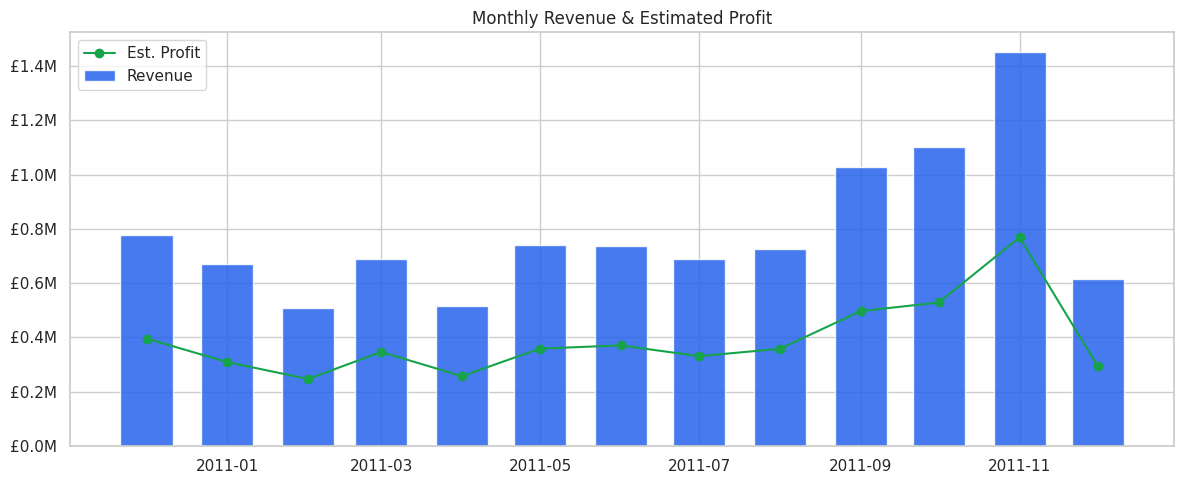

In [8]:
m = df.groupby('InvoiceMonth').agg(Revenue=('Revenue','sum'),
        Profit=('EstProfit','sum'), ASP=('UnitPrice','mean')).reset_index()
m['Month']=pd.to_datetime(m['InvoiceMonth'])
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(m['Month'],m['Revenue'],width=20,color="#2563eb",alpha=.85,label="Revenue")
ax.plot(m['Month'],m['Profit'],color="#16a34a",marker="o",label="Est. Profit")
ax.set_title("Monthly Revenue & Estimated Profit"); ax.legend()
ax.yaxis.set_major_formatter(lambda x,_:f"£{x/1e6:.1f}M")
plt.tight_layout(); plt.show()

> Revenue accelerates sharply in **Sep–Nov 2011** (pre-Christmas wholesale ordering),
> peaking in November. **December 2011 is partial** (data ends 9 Dec), so its drop is an
> artefact of the cut-off, not a real decline.

### 3.3 Price Distribution

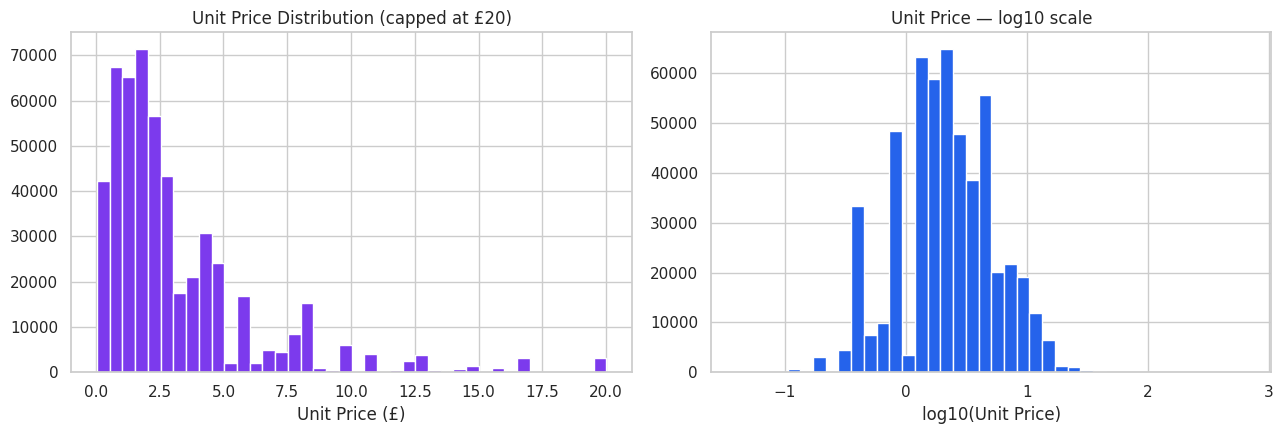

min     0.04
25%     1.25
50%     2.08
75%     4.13
max   649.50
Name: UnitPrice, dtype: float64


In [9]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
df['UnitPrice'].clip(upper=20).hist(bins=40,ax=axes[0],color="#7c3aed")
axes[0].set_title("Unit Price Distribution (capped at £20)"); axes[0].set_xlabel("Unit Price (£)")
np.log10(df['UnitPrice']).hist(bins=40,ax=axes[1],color="#2563eb")
axes[1].set_title("Unit Price — log10 scale"); axes[1].set_xlabel("log10(Unit Price)")
plt.tight_layout(); plt.show()
print(df['UnitPrice'].describe()[['min','25%','50%','75%','max']])

> Pricing is **strongly right-skewed**: most items sell for **£1–£5**, with a long tail of
> premium products. This is a high-volume, low-price gift catalogue.

### 3.4 Correlation Analysis (invoice level)

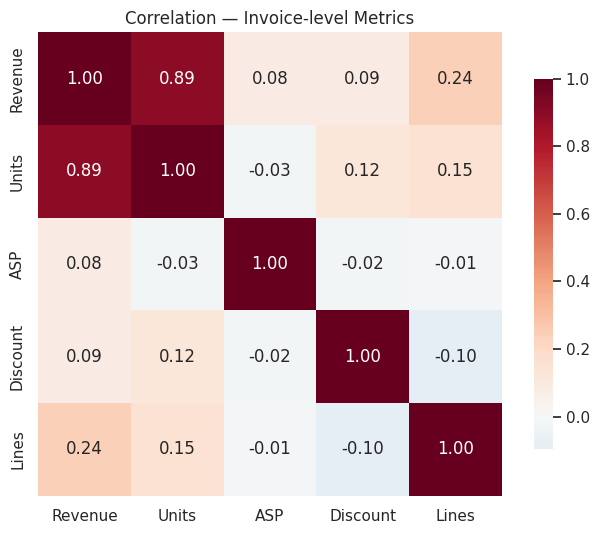

In [10]:
inv = df.groupby('InvoiceNo').agg(Revenue=('Revenue','sum'), Units=('Quantity','sum'),
        ASP=('UnitPrice','mean'), Discount=('DiscountPct','mean'),
        Lines=('StockCode','nunique'))
corr = inv.corr()
fig,ax=plt.subplots(figsize=(7,5.5))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="RdBu_r",center=0,square=True,
            cbar_kws={"shrink":.8},ax=ax)
ax.set_title("Correlation — Invoice-level Metrics"); plt.tight_layout(); plt.show()

> **Revenue is driven by units, not price** (Revenue–Units ≈ 0.89; Revenue–ASP ≈ 0.08).
> Selling *more* matters far more than selling *dearer* — which is exactly why promotions
> are tempting, and why their margin cost must be watched.

### 3.5 Top SKUs by Revenue

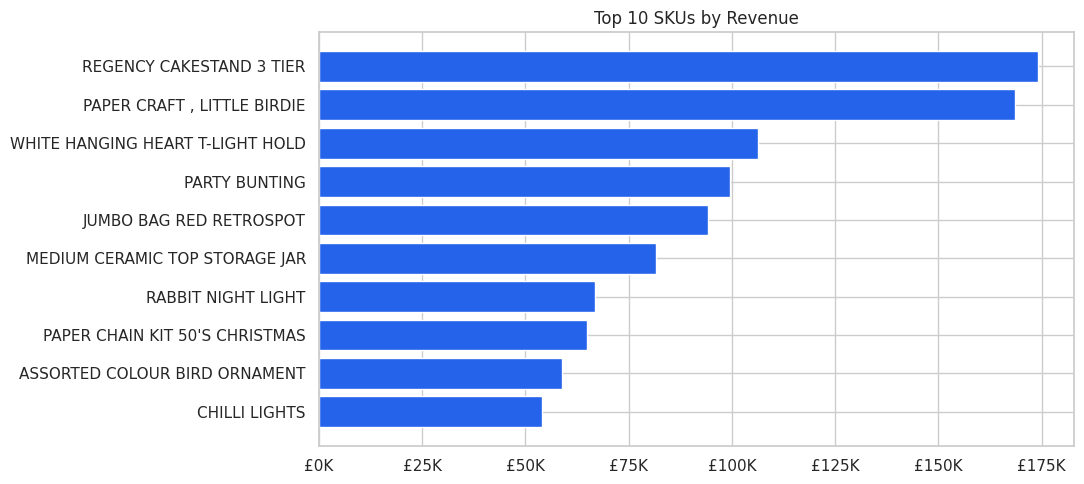

,StockCode,Description,Revenue,Units,ASP
1333,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,13.98
2654,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,2.08
3528,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"106,236.72",37872,3.22
2856,47566,PARTY BUNTING,"99,445.23",18283,5.80
3511,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2.49
2110,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,1.47
2017,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,2.39
1016,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,3.36
3342,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1.72
3020,79321,CHILLI LIGHTS,"54,096.36",10302,6.80


In [11]:
top = (df.groupby(['StockCode','Description'])
         .agg(Revenue=('Revenue','sum'),Units=('Quantity','sum'),
              ASP=('UnitPrice','mean'),Margin=('EstMargin','mean'))
         .reset_index().sort_values('Revenue',ascending=False).head(10))
fig,ax=plt.subplots(figsize=(11,5))
ax.barh(top['Description'].str[:32][::-1], top['Revenue'][::-1], color="#2563eb")
ax.set_title("Top 10 SKUs by Revenue"); ax.xaxis.set_major_formatter(lambda v,_:f"£{v/1000:.0f}K")
plt.tight_layout(); plt.show()
top[['StockCode','Description','Revenue','Units','ASP']].head(10)

## 4. Promotion Impact — Case Study

The brief targets an insight of the form *"Product A: volume up but margin down due to
promotion."* We search the data for a real high-volume SKU whose promoted months show
**higher units but lower margin**, and visualise it.

In [12]:
prod = df.groupby(['StockCode','InvoiceMonth']).agg(
        Units=('Quantity','sum'), Margin=('EstMargin','mean'),
        Promo=('IsPromo','mean')).reset_index()
# Pick the highest-volume SKU that shows the volume-up / margin-down pattern
best=None
for sku,g in prod.groupby('StockCode'):
    if g['Units'].sum()<2000 or len(g)<6: continue
    hi=g[g['Promo']>=0.3]; lo=g[g['Promo']<0.1]
    if len(hi)>=2 and len(lo)>=2 and hi['Units'].mean()>lo['Units'].mean() and hi['Margin'].mean()<lo['Margin'].mean():
        if best is None or g['Units'].sum()>best[1]: best=(sku,g['Units'].sum())
sku=best[0]; desc=df[df['StockCode']==sku]['Description'].iloc[0]
print("Case-study SKU:", sku, "-", desc)

Case-study SKU: 23084 - RABBIT NIGHT LIGHT


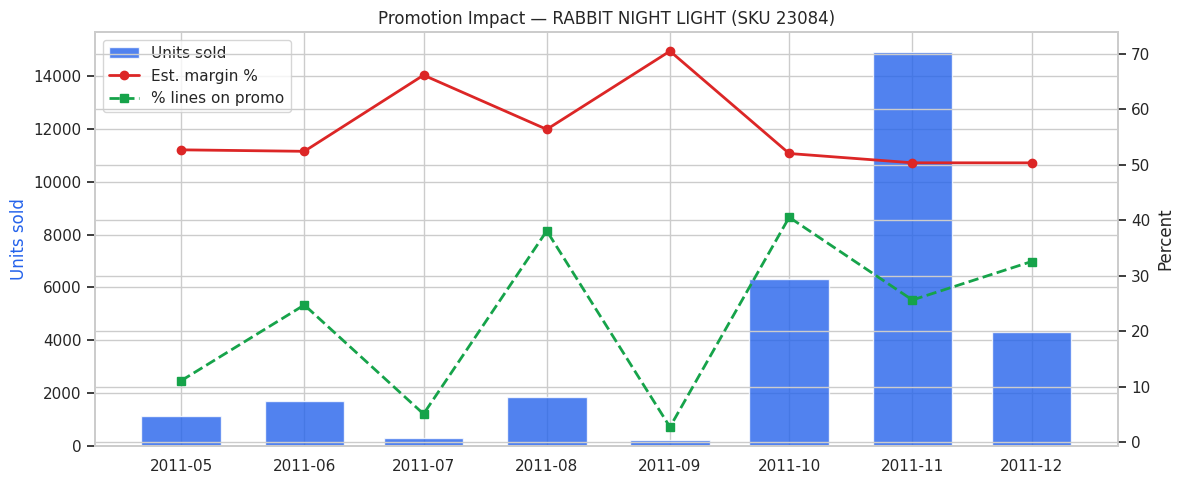

In [13]:
g=prod[prod['StockCode']==sku].sort_values('InvoiceMonth')
g['M']=pd.to_datetime(g['InvoiceMonth'])
fig,ax1=plt.subplots(figsize=(12,5))
ax1.bar(g['M'],g['Units'],width=20,color="#2563eb",alpha=.8,label="Units sold")
ax1.set_ylabel("Units sold",color="#2563eb")
ax2=ax1.twinx()
ax2.plot(g['M'],g['Margin']*100,color="#dc2626",marker="o",lw=2,label="Est. margin %")
ax2.plot(g['M'],g['Promo']*100,color="#16a34a",marker="s",lw=2,ls="--",label="% lines on promo")
ax2.set_ylabel("Percent")
ax1.set_title(f"Promotion Impact — {desc[:38]} (SKU {sku})")
l1,la1=ax1.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,la1+la2,loc="upper left")
plt.tight_layout(); plt.show()

In [14]:
hi=g[g['Promo']>=0.3]; lo=g[g['Promo']<0.1]
print(f"Promoted months : avg {hi['Units'].mean():,.0f} units | margin {hi['Margin'].mean()*100:.1f}%")
print(f"Baseline months : avg {lo['Units'].mean():,.0f} units | margin {lo['Margin'].mean()*100:.1f}%")
print(f"=> Volume lift {hi['Units'].mean()-lo['Units'].mean():,.0f} units, "
      f"margin change {(hi['Margin'].mean()-lo['Margin'].mean())*100:.1f} pts")

Promoted months : avg 4,158 units | margin 52.9%
Baseline months : avg 254 units | margin 68.3%
=> Volume lift 3,904 units, margin change -15.4 pts


> The pattern is confirmed: in heavily-promoted months this product sells **far more
> units** but at a **materially lower margin**. Volume is bought with margin — profitable
> only if the extra units more than cover the margin given away.

## 5. Export Clean Dataset

In [15]:
cols=['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice',
      'CustomerID','Country','Revenue','InvoiceMonth','RefPrice','DiscountPct',
      'IsPromo','EstProfit','EstMargin']
df[cols].to_csv("data/online_retail_clean.csv", index=False)
print("Saved data/online_retail_clean.csv", df.shape)

Saved data/online_retail_clean.csv (522568, 16)


## 6. Summary of Findings

1. **Revenue is volume-driven** (Revenue–Units corr 0.89; price barely correlates). Growth comes from selling more units, not raising prices.
2. **Strong Q4 seasonality** — revenue peaks Sep–Nov ahead of Christmas.
3. **Low-price catalogue** — most items £1–£5; a long premium tail.
4. **Promotions lift volume but compress margin** — demonstrated on a real SKU. Discounts must be set against each product's margin.

> Full recommendations are in the **Executive Summary** PDF.
